#### 1.Carga de datos

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_parquet("../data/processed/events_clean.parquet")
df.head(2)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00+00:00,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00+00:00,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283


#### 2.Distribución de variables

In [4]:
event_count = df["event_type"].value_counts()
event_count

event_type
view        966252
purchase     17817
cart         14958
Name: count, dtype: int64

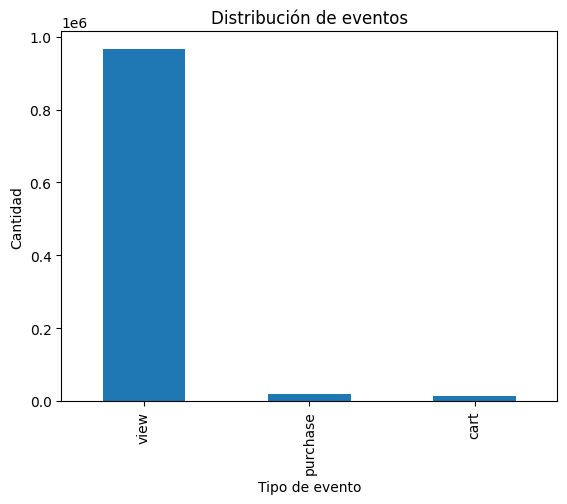

In [5]:
event_count.plot(kind="bar")
plt.title("Distribución de eventos")
plt.xlabel("Tipo de evento")
plt.ylabel("Cantidad")
plt.show()

#### 3.Funnel por usuarios

In [6]:
funnel = df.groupby("event_type")["user_id"].unique()
funnel

event_type
cart        [533326659, 557746614, 565865924, 549256216, 5...
purchase    [559368633, 513351129, 562958505, 541854711, 5...
view        [520088904, 530496790, 561587266, 518085591, 5...
Name: user_id, dtype: object

#### 4.Métricas de conversión

In [7]:
carts = df[df["event_type"] == "cart"]["user_id"].nunique()
purchases = df[df["event_type"] == "purchase"]["user_id"].nunique()
views = df[df["event_type"] == "view"]["user_id"].nunique()

In [8]:
print(carts, purchases, views)

8375 13229 170260


In [9]:
view_to_cart = carts/views
cart_to_purchase = purchases/carts
view_to_purchase = purchases/views

view_to_cart, cart_to_purchase, view_to_purchase

(0.049189474920709506, 1.5795820895522388, 0.07769881357923177)

#### 5.Construcción de funnel por usuario

In [10]:
funnel_users = df.groupby("user_id")["event_type"].unique()
funnel_users.head()

user_id
274969076    [view]
275256741    [view]
295643776    [view]
296465302    [view]
319315209    [view]
Name: event_type, dtype: object

In [11]:
funnel_df = funnel_users.apply(lambda x: {
    "view": "view" in x,
    "cart": "cart" in x,
    "purchase": "purchase" in x
}).apply(pd.Series)

funnel_df.head()

,view,cart,purchase
user_id,,,
274969076,True,False,False
275256741,True,False,False
295643776,True,False,False
296465302,True,False,False
319315209,True,False,False


#### 6.Usuarios por etapa del funnel

In [12]:
views = funnel_df["view"].sum()
carts = (funnel_df["view"] & funnel_df["cart"]).sum()
purchases = (funnel_df["view"] & funnel_df["cart"] & funnel_df["purchase"]).sum()

views, carts, purchases

(np.int64(170260), np.int64(8363), np.int64(4983))

#### 7.Métricas de conversión corregidas

In [13]:
view_to_cart = carts/views
cart_to_purchase = purchases/carts
view_to_purchase = purchases/views

view_to_cart, cart_to_purchase, view_to_purchase

(np.float64(0.04911899447903207),
 np.float64(0.5958388138227909),
 np.float64(0.029267003406554682))

#### 8.Visualización del funnel

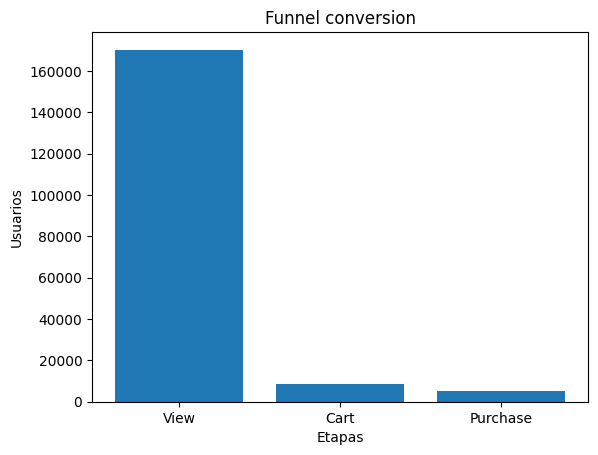

In [14]:
stages = ["View", "Cart", "Purchase"]
values = [views, carts, purchases]

plt.figure()
plt.bar(stages, values)
plt.title("Funnel conversion")
plt.xlabel("Etapas")
plt.ylabel("Usuarios")
plt.show()

#### 9.Tasas de conversión

In [15]:
print(f"View -> Cart: {view_to_cart:.2%}")
print(f"Cart -> Purchase: {cart_to_purchase:.2%}")
print(f"View -> Purchase: {view_to_purchase:.2%}")

View -> Cart: 4.91%
Cart -> Purchase: 59.58%
View -> Purchase: 2.93%


#### 10.Funnel de conversión por categoría

In [16]:
df_category = df.copy()
df_category = df_category[df_category["category_code"] != "unknow"]

#### 11.Construcción del funnel por categoría y usuario

In [17]:
funnel_category = (
    df_category
    .groupby(["category_code", "user_id", "event_type"])
    .size()
    .unstack(fill_value=0)
    .gt(0)
    .reset_index()
)

funnel_category.head()

event_type,category_code,user_id,cart,purchase,view
0,accessories.bag,503919917,False,False,True
1,accessories.bag,512174135,False,False,True
2,accessories.bag,512367412,False,False,True
3,accessories.bag,512370287,False,False,True
4,accessories.bag,512372291,False,False,True


#### 12.Métricas de conversión por categoría

In [18]:
results = []

for category, group in funnel_category.groupby("category_code"):
    views = group["view"].sum()
    carts = (group["view"] & group["cart"]).sum()
    purchases = (group["view"] & group["cart"] & group["purchase"]).sum()

    if views > 0 and carts > 0:
        results.append({
            "category": category,
            "view_to_cart": carts/views,
            "cart_to_purchase": purchases/carts,
            "view_to_purchase": purchases/views
        })
    
    df_results = pd.DataFrame(results)

In [19]:
df_results.head()

,category,view_to_cart,cart_to_purchase,view_to_purchase
0,accessories.bag,0.000870,1.000000,0.000870
1,appliances.environment.air_heater,0.029070,0.700000,0.020349
2,appliances.environment.vacuum,0.029968,0.598361,0.017932
3,appliances.environment.water_heater,0.025000,0.666667,0.016667
4,appliances.iron,0.006046,1.000000,0.006046


#### 13.Top categorías por cenversión

In [20]:
df_results.sort_values("view_to_purchase", ascending=False).head(10)

,category,view_to_cart,cart_to_purchase,view_to_purchase
48,electronics.smartphone,0.094035,0.633286,0.059551
44,electronics.audio.headphone,0.066971,0.541436,0.036260
22,auto.accessories.alarm,0.041332,0.611111,0.025258
37,computers.peripherals.printer,0.038224,0.645161,0.024661
52,electronics.video.tv,0.047538,0.503247,0.023923
63,medicine.tools.tonometer,0.032258,0.666667,0.021505
28,computers.components.hdd,0.030928,0.666667,0.020619
50,electronics.telephone,0.042988,0.475410,0.020437
1,appliances.environment.air_heater,0.029070,0.700000,0.020349
49,electronics.tablet,0.034205,0.544118,0.018612


### Análisis del funnel por rango de precios

#### 14.Creación de rangos de precios

In [21]:
bins = [0, 50, 150, 300, 600, 1000, df["price"].max()]
labels = ["0-50", "50-150", "150-300", "300-600", "600-1000", "1000+"]

df["price_range"] = pd.cut(df["price"], bins=bins, labels=labels)
df[["price", "price_range"]].head()

,price,price_range
0,489.07,300-600
1,293.65,150-300
2,28.31,0-50
3,712.87,600-1000
4,183.27,150-300


#### 15.Construcción del funnel de precio y usuario

In [22]:
funnel_price = (
    df.groupby(["price_range", "user_id", "event_type"], observed=True)
    .size()
    .unstack(fill_value=0)
    .gt(0)
    .reset_index()
)

funnel_price.head()

event_type,price_range,user_id,cart,purchase,view
0,0-50,296465302,False,False,True
1,0-50,319315209,False,False,True
2,0-50,323962106,False,False,True
3,0-50,333288876,False,False,True
4,0-50,346207313,False,False,True


#### 16.Métricas de conversión por rango de precio

In [23]:
results_price = []

for price_range, group in funnel_price.groupby("price_range", observed=True):
    views = group["view"].sum()
    carts = (group["view"] & group["cart"]).sum()
    purchases = (group["view"] & group["cart"] & group["purchase"]).sum()

    if views > 0 and carts > 0:
        results_price.append({
            "price_range": price_range,
            "view_to_cart": carts/views,
            "cart_to_purchase": purchases/carts,
            "view_to_purchase": purchases/views
        })

df_price_results = pd.DataFrame(results_price)

In [24]:
df_price_results.head()

,price_range,view_to_cart,cart_to_purchase,view_to_purchase
0,0-50,0.018855,0.445567,0.008401
1,50-150,0.028409,0.584661,0.016610
2,150-300,0.043191,0.619527,0.026758
3,300-600,0.027103,0.619149,0.016781
4,600-1000,0.033802,0.597549,0.020198


#### 17.Visualización de conversión por rango de precio

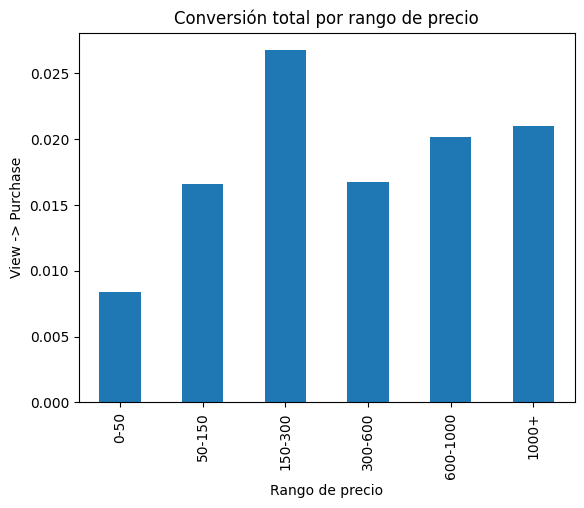

In [25]:
df_price_results.set_index("price_range")["view_to_purchase"].plot(kind="bar")
plt.title("Conversión total por rango de precio")
plt.xlabel("Rango de precio")
plt.ylabel("View -> Purchase")
plt.show()

#### 18. Top de productos en el rango de precios óptimo (150-300)

In [26]:
df_optimal = df[df["price_range"] == "150-300"]
df_optimal.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,price_range
1,2019-11-01 00:00:00+00:00,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283,150-300
4,2019-11-01 00:00:01+00:00,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2,150-300
11,2019-11-01 00:00:03+00:00,view,2701517,2053013563911439225,appliances.kitchen.refrigerators,unknown,155.11,518427361,c89b0d96-247f-4044-9c91-bb5f38c6af9b,150-300
18,2019-11-01 00:00:07+00:00,view,1004566,2053013555631882655,electronics.smartphone,huawei,164.84,566265908,52c2c76c-b79e-4794-86ff-badc76d35f5a,150-300
21,2019-11-01 00:00:08+00:00,view,1004708,2053013555631882655,electronics.smartphone,huawei,151.99,566143627,aa610ab3-5c60-4551-8a2b-8c999dddf843,150-300


#### 19.Productos más vendidos en el rango 150-300

In [27]:
top_products = (
    df_optimal[df_optimal["event_type"] == "purchase"]
    .groupby("product_id")
    .size()
    .sort_values(ascending=False)
    .head(10)
)
top_products

product_id
1004767    503
1004833    375
4804056    290
1004870    236
1004836    197
1004741    126
1005160     98
1004838     93
1004750     86
1004565     76
dtype: int64

#### 20.Productos con mejor conversión en el rango 150-300

In [28]:
funnel_products = (
    df_optimal
    .groupby(["product_id", "user_id", "event_type"])
    .size()
    .unstack(fill_value=0)
    .gt(0)
    .reset_index()
)

In [37]:
results_products = []
for product, group in funnel_products.groupby("product_id"):
    views = group["view"].sum()
    carts = (group["view"] & group["cart"]).sum()
    purchases = (group["view"] & group["cart"] & group["purchase"]).sum()

    if views > 50 and carts > 10:
        results_products.append({
            "product_id": product,
            "view_to_purchase": purchases/views
        })

df_product_results = pd.DataFrame(results_products)

In [38]:
df_product_results.sort_values("view_to_purchase", ascending=False).head(10)

,product_id,view_to_purchase
15,1004833,0.067837
18,1004836,0.064017
46,4804056,0.061545
16,1004834,0.061364
21,1004863,0.061170
20,1004839,0.049658
22,1004870,0.048551
9,1004767,0.048375
1,1004566,0.043478
0,1004565,0.039514
